In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [ ]:
import torch
import torch.optim as optim

from utils.model import build_resnet50
from utils.checkpoint import load_checkpoint
from utils.dataloaders import create_dataloaders
from utils.iegef_optimizer import IEGEFLoss
from utils.iegef_trainer import train_model

from utils.attention_loss import AttentionAlignmentLoss
from utils.model import build_resnet50
from utils.checkpoint import load_checkpoint
from utils.dataloaders import create_dataloaders

In [3]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print(device)

mps


In [ ]:
train_loader, val_loader, test_loader, *_ = create_dataloaders(
    dataset_path="../datasets/COVID-19_Radiography_Dataset",
    batch_size=16,
    load_masks=True
)

tensor(0.6485)


In [ ]:
model = build_resnet50(
    num_classes=4,
    pretrained=False
)

model = load_checkpoint(
    model,
    "../checkpoints/best_resnet50.pth",
    device
)

model = model.to(device)

print("Baseline model loaded successfully.")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [ ]:
criterion = IEGEFLoss(
    lambda_attention=0.3
)

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

torch.Size([16, 1, 7, 7])


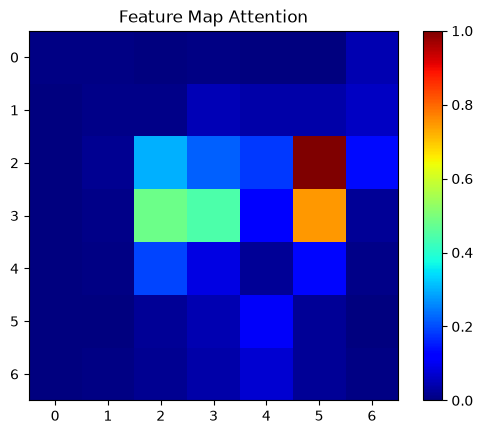

In [ ]:
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [ ]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    epochs=10,
    patience=5
)

Total : 1.9914947748184204
Cls   : 1.8420369625091553
Att   : 0.49819260835647583
